# Phần 1 (batch size = 2) — Deep Leakage from Gradients (DLG) & iDLG trên LeNet, kèm DP-SGD defense

**Pillar:** Security — privacy trong Federated Learning (FL).

**Claim under test:** *"In Federated Learning, raw data never leaves the device — only gradients are shared."*
Notebook này cho thấy chỉ từ **gradient của một client tính trên batch 2 ảnh (batch size = 2)**, attacker có thể **reconstruct cả hai ground-truth image** của client đó. Đây là phiên bản mở rộng của `part1.ipynb` (batch size = 1): gradient là **trung bình** của hai ảnh nên hai ảnh bị trộn vào cùng một vector gradient.

**Contents:**
1. **DLG** (Zhu et al., NeurIPS 2019) — jointly optimize *dummy image* và *dummy label* sao cho gradient của chúng match với leaked gradient. Code lấy từ notebook Colab chính thức của tác giả.
2. **iDLG** (Zhao et al., 2020) — recover *ground-truth label* bằng closed-form từ gradient (với batch size = 2: lấy **2 hàng có tổng gradient âm nhất** của lớp cuối, xem mục 5), sau đó chỉ optimize dummy image. Code bám theo repo của tác giả: https://github.com/PatrickZH/Improved-Deep-Leakage-from-Gradients
3. **DP-SGD defense** (Abadi et al., 2016) — clip L2 norm của gradient rồi cộng Gaussian noise *trước khi* chia sẻ, để đo mức protection mà nó mang lại.

**Model:** LeNet (4 khối Conv + Sigmoid, không MaxPool/BatchNorm). **Dataset:** CIFAR-10, mỗi lần **hai ảnh khác class** (batch size = 2) — cùng dataset với Part 2 (ResNet-50 + Inverting Gradients) để so sánh trực tiếp.

## 1. Imports, dataset CIFAR-10 và helper functions

- `torch.manual_seed(50)` để kết quả reproducible.
- `label_to_onehot`: đổi label (số nguyên) thành vector one-hot (10 class của CIFAR-10).
- `cross_entropy_for_onehot`: cross-entropy nhận **soft label** (phân phối xác suất) thay vì class index:
$$\mathcal{L}(z, y) = -\sum_{c} y_c \log \mathrm{softmax}(z)_c$$
  Cần dạng này vì DLG optimize *dummy label* dưới dạng phân phối liên tục (qua softmax), còn label thật chỉ là trường hợp one-hot.

In [12]:
%matplotlib inline

import numpy as np
from pprint import pprint

from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
import torchvision
from torchvision import models, datasets, transforms
torch.manual_seed(50)

print(torch.__version__, torchvision.__version__)

2.10.0+cu128 0.25.0+cu128


In [13]:
dst = datasets.CIFAR10("./data")
tp = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor()
])
tt = transforms.ToPILImage()

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
print("Running on %s" % device)

def label_to_onehot(target, num_classes=10):
    target = torch.unsqueeze(target, 1)
    onehot_target = torch.zeros(target.size(0), num_classes, device=target.device)
    onehot_target.scatter_(1, target, 1)
    return onehot_target

def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(- target * F.log_softmax(pred, dim=-1), 1))

def to_pil_list(x):
    # a batch of tensors -> list of PIL images (used to record the optimisation history of every image in the batch)
    return [tt(xi.detach().cpu()) for xi in x]

def match_mse(rec, gt):
    # The gradient of a batch is invariant to permuting the (image, label) pairs inside the batch, so the attacker cannot know
    # which dummy image belongs to which ground-truth image. We match every reconstruction to a ground-truth image with the
    # permutation that gives the smallest total MSE. Returns (reconstructions re-ordered like gt, per-image MSE).
    import itertools
    best = None
    for perm in itertools.permutations(range(gt.size(0))):          # perm[i] = index of the gt image matched to rec[i]
        per_img = torch.stack([torch.mean((rec[i].detach() - gt[p]) ** 2) for i, p in enumerate(perm)])
        if best is None or per_img.sum() < best[1].sum():
            best = (perm, per_img)
    perm, per_img = best
    aligned = torch.empty_like(rec.detach())
    aligned[list(perm)] = rec.detach()
    mse_gt_order = torch.empty_like(per_img)
    mse_gt_order[list(perm)] = per_img
    return aligned, mse_gt_order

def show_history(hist, title, n_milestones=10):
    # hist[k][b] = image b after k+1 optimisation steps. Show n_milestones evenly spaced steps (first and last included),
    # one row per image of the batch.
    steps = np.unique(np.round(np.linspace(0, len(hist) - 1, n_milestones)).astype(int))
    plt.figure(figsize=(1.6 * len(steps), 1.9 * BATCH_SIZE + 0.6))
    for b in range(BATCH_SIZE):
        for c, k in enumerate(steps):
            plt.subplot(BATCH_SIZE, len(steps), b * len(steps) + c + 1)
            plt.imshow(hist[k][b])
            plt.title("iter=%d" % (k + 1), fontsize=8)
            if c == 0:
                plt.ylabel("image %d" % b, fontsize=8)
            plt.xticks([]); plt.yticks([])
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Running on cuda


## 2. Victim model — LeNet với Sigmoid

$$f_\theta(x) = W_{fc}\,\sigma\big(\mathrm{Conv}_4(\sigma(\mathrm{Conv}_3(\sigma(\mathrm{Conv}_2(\sigma(\mathrm{Conv}_1(x)))))))\big) + b_{fc}$$

- DLG optimize **input image** thông qua *gradient của gradient* (xem mục 4), nên loss phải differentiable hai lần theo $x$.
  ReLU có second derivative bằng 0 hầu như mọi nơi, còn MaxPool/BatchNorm làm loss surface kém smooth hoặc phụ thuộc batch,
  nên đều làm yếu tín hiệu optimization của attacker. **Sigmoid** smooth ($C^\infty$) nên được chọn.
- `weights_init` khởi tạo weights và bias theo $\mathrm{Uniform}(-0.5, 0.5)$ — model gần trạng thái random init,
  tương ứng threat model: attacker eavesdrop ở **những round FL đầu tiên** (đúng theo bài báo).
- Lớp fully-connected cuối có 10 output (10 class của CIFAR-10).

In [14]:
def weights_init(m):
    if hasattr(m, "weight"):
        m.weight.data.uniform_(-0.5, 0.5)
    if hasattr(m, "bias"):
        m.bias.data.uniform_(-0.5, 0.5)

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        act = nn.Sigmoid
        self.body = nn.Sequential(
            nn.Conv2d(3, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
        )
        self.fc = nn.Sequential(
            nn.Linear(768, 10)
        )

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        # print(out.size())
        out = self.fc(out)
        return out

net = LeNet().to(device)

net.apply(weights_init)
criterion = cross_entropy_for_onehot

## 3. Mô phỏng một bước training của client FL (batch size = 2)

Client (honest participant) tính gradient cục bộ trên **batch gồm hai ảnh private** $\{(x_b, y_b)\}_{b=1}^{2}$ rồi gửi cho server:

$$\Delta w = \nabla_\theta\,\frac{1}{2}\sum_{b=1}^{2}\mathcal{L}\big(f_\theta(x_b),\, y_b\big)$$

Attacker (honest-but-curious server hoặc eavesdropper) **chỉ quan sát $\Delta w$** (`original_dy_dx`), không thấy $(x_b, y_b)$.
Mục tiêu của attacker: reconstruct **cả hai** ảnh (và label) chỉ từ $\Delta w$.

So với batch size = 1, bài toán khó hơn vì hai lý do:

- $\Delta w$ là **trung bình** của gradient hai ảnh, nên thông tin của hai ảnh bị trộn lẫn vào cùng một vector.
- $\Delta w$ **không đổi khi hoán vị** cặp $(x_1, y_1) \leftrightarrow (x_2, y_2)$, nên thứ tự các ảnh reconstruct không xác định. Khi đánh giá, mỗi ảnh reconstruct được ghép với ảnh gốc gần nhất (hàm `match_mse` ở mục 1) — chỉ dùng để tính metric, không ảnh hưởng đến attack.

Hai ảnh được chọn thuộc **hai class khác nhau** (điều kiện để bước recover label ở mục 5 hoạt động).

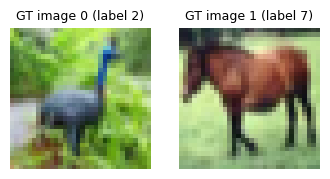

Batch size is 2.
GT labels are [2, 7] 
Onehot labels are [2, 7]


In [15]:
######### honest partipant #########
img_indices = [6]
# pick a second image with a different class (the label recovery of section 5 needs distinct labels)
j = img_indices[0] + 1
while dst[j][1] == dst[img_indices[0]][1]:
    j += 1
img_indices.append(j)
BATCH_SIZE = len(img_indices)

gt_data = torch.stack([tp(dst[i][0]) for i in img_indices]).to(device)          # [2, 3, 32, 32]
gt_label = torch.Tensor([dst[i][1] for i in img_indices]).long().to(device)     # [2]
gt_onehot_label = label_to_onehot(gt_label, num_classes=10)                     # [2, 10]

plt.figure(figsize=(4, 2.4))
for b in range(BATCH_SIZE):
    plt.subplot(1, BATCH_SIZE, b + 1)
    plt.imshow(tt(gt_data[b].cpu()))
    plt.title("GT image %d (label %d)" % (b, gt_label[b].item()), fontsize=9)
    plt.axis('off')
plt.show()
print("Batch size is %d." % BATCH_SIZE)
print("GT labels are", gt_label.tolist(), "\nOnehot labels are", torch.argmax(gt_onehot_label, dim=-1).tolist())

# compute original gradient (the loss is the mean over the batch)
out = net(gt_data)
y = criterion(out, gt_onehot_label)
dy_dx = torch.autograd.grad(y, net.parameters())


# share the gradients with other clients
original_dy_dx = list((_.detach().clone() for _ in dy_dx))

## 4. DLG attack (Zhu et al., NeurIPS 2019)

Bắt đầu từ dummy image $x'$ và dummy label $y'$ (dummy image khởi tạo ngẫu nhiên đều trong $[0, 1]$ bằng `torch.rand`, dummy label bằng `torch.randn`), DLG tìm cặp $(x', y')$ sao cho gradient sinh ra match với leaked gradient:

$$x^{*}, y'^{*} \;=\; \arg\min_{x',\, y'} \; \Big\lVert\, \nabla_\theta\,\mathcal{L}\big(f_\theta(x'), y'\big) \;-\; \Delta w \,\Big\rVert_2^2$$

Với batch size = 2, attacker dùng **hai dummy image và hai dummy label** (một cặp cho mỗi ảnh của batch), và dummy gradient cũng là **trung bình** trên batch để cùng dạng với $\Delta w$. Ở bước khởi tạo dưới đây, `dummy_data` là 2 ảnh noise và `dummy_label` là 2 vector logit ngẫu nhiên (10 chiều).

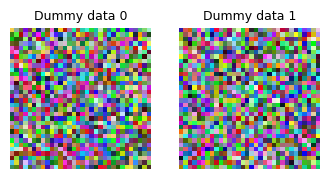

Dummy labels are [6, 3]


In [16]:
# generate dummy data and label (one dummy image / label per image of the batch)
dummy_data = torch.rand(gt_data.size()).to(device).requires_grad_(True)      # uniform [0, 1]
dummy_label = torch.randn(gt_onehot_label.size()).to(device).requires_grad_(True)

plt.figure(figsize=(4, 2.4))
for b in range(BATCH_SIZE):
    plt.subplot(1, BATCH_SIZE, b + 1)
    plt.imshow(tt(dummy_data[b].detach().cpu()))
    plt.title("Dummy data %d" % b, fontsize=9)
    plt.axis('off')
plt.show()
print("Dummy labels are", torch.argmax(dummy_label, dim=-1).tolist())

### Optimization loop của DLG

- Objective tự nó được xây từ một gradient của $\mathcal L$ (`torch.autograd.grad(..., create_graph=True)`), nên optimize theo $x'$ đòi hỏi
  backpropagate qua gradient đó thêm một lần nữa (**double backprop**).
- Dummy label được đưa qua `softmax` để thành soft label; `dummy_data` và `dummy_label` được optimize **đồng thời** bằng **L-BFGS**
  (`torch.optim.LBFGS`, default parameters, `lr = 1`), 300 iterations.
- `grad_diff` = tổng bình phương chênh lệch giữa dummy gradient và ground-truth gradient trên mọi parameter. Loss càng nhỏ, dummy image càng gần ground-truth image.

In [17]:
optimizer = torch.optim.LBFGS([dummy_data, dummy_label] )

history = []
for iters in range(300):
    def closure():
        optimizer.zero_grad()

        pred = net(dummy_data)
        dummy_onehot_label = F.softmax(dummy_label, dim=-1)
        dummy_loss = criterion(pred, dummy_onehot_label) # TODO: fix the gt_label to dummy_label in both code and slides.
        dummy_dy_dx = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

        grad_diff = 0
        grad_count = 0
        for gx, gy in zip(dummy_dy_dx, original_dy_dx): # TODO: fix the variablas here
            grad_diff += ((gx - gy) ** 2).sum()
            grad_count += gx.nelement()
        # grad_diff = grad_diff / grad_count * 1000
        grad_diff.backward()

        return grad_diff

    optimizer.step(closure)
    if iters % 10 == 0:
        current_loss = closure()
        print(iters, "%.4f" % current_loss.item())
    history.append(to_pil_list(dummy_data))

0 2.8217
10 0.0064
20 0.0022
30 0.0014
40 0.0010
50 0.0008
60 0.0006
70 0.0005
80 0.0005
90 0.0004
100 0.0004
110 0.0003
120 0.0003
130 0.0003
140 0.0003
150 0.0002
160 0.0002
170 0.0002
180 0.0002
190 0.0002
200 0.0002
210 0.0002
220 0.0002
230 0.0002
240 0.0002
250 0.0001
260 0.0001
270 0.0001
280 0.0001
290 0.0001


### Kết quả DLG

Mỗi hàng của figure ứng với **một dummy image** (dummy image 0 và 1); mỗi ô là dummy image ở một trong **10 mốc iteration cách đều nhau** (từ iteration đầu tiên đến iteration cuối cùng). Nếu attack thành công, ảnh sẽ dần chuyển từ noise sang một trong hai ground-truth image ở mục 3 — **không nhất thiết theo cùng thứ tự** (xem mục 3).
Dòng in ra bên dưới là các label mà DLG tìm được (`argmax` của `dummy_label`) — DLG optimize label cùng ảnh nên **không đảm bảo** đúng label thật.

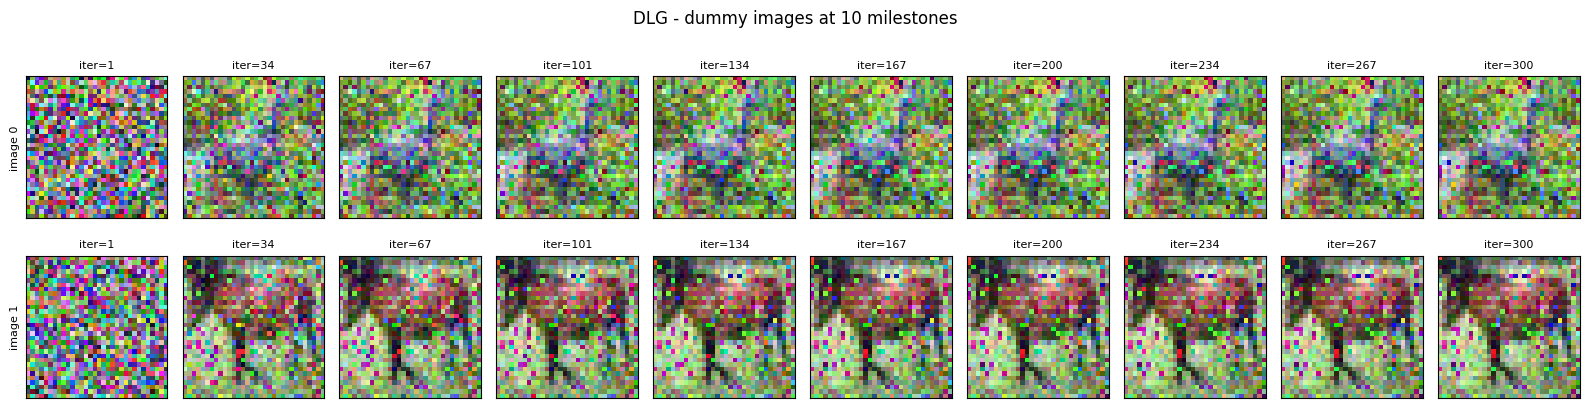

Dummy labels are [2, 7] | GT labels are [2, 7]


In [18]:
show_history(history, "DLG - dummy images at 10 milestones")
print("Dummy labels are", torch.argmax(dummy_label, dim=-1).tolist(), "| GT labels are", gt_label.tolist())

## 5. iDLG attack — closed-form label + chỉ optimize ảnh (Zhao et al., 2020), mở rộng cho batch size = 2

Dùng lại cùng `net`, cùng batch ground-truth và cùng leaked gradient `original_dy_dx` như DLG.

**Recover label trong một bước.** Với cross-entropy, gradient theo hàng $i$ của weight lớp cuối (loss trung bình trên batch) là

$$\frac{\partial \mathcal{L}}{\partial W_{i}} = \frac{1}{2}\sum_{b=1}^{2}\big(\mathrm{softmax}(z_b)_i - \mathbb{1}[i = y_b]\big)\, h_b^{\top}$$

trong đó $h_b$ là feature vector đầu vào của lớp cuối (output của Sigmoid nên $h_{b,j} > 0$). Tổng theo các cột:

$$\sum_j \frac{\partial \mathcal{L}}{\partial W_{ij}} = \frac{1}{2}\sum_{b=1}^{2}\big(\mathrm{softmax}(z_b)_i - \mathbb{1}[i = y_b]\big)\, s_b, \qquad s_b = \sum_j h_{b,j} > 0.$$

Với batch size = 1 chỉ có đúng một hàng âm (class thật), nên $\hat y = \arg\min_i \sum_j \partial\mathcal{L}/\partial W_{ij}$ **luôn đúng**. Với batch size = 2, hàng của class $y_b$ có một số hạng âm $(\mathrm{softmax}_i - 1)\,s_b$ nhưng cộng thêm số hạng dương từ ảnh còn lại, nên **không còn đảm bảo tuyệt đối**; khi model gần trạng thái random init (softmax gần đều), số hạng âm áp đảo và **hai hàng có tổng nhỏ nhất** chính là hai class có trong batch:

$$\hat{\mathcal{Y}} = \operatorname{argsort}_i\Big(\sum_j \frac{\partial \mathcal{L}}{\partial W_{ij}}\Big)_{[:2]}$$

Hai lưu ý: (i) hai ảnh phải **khác class** (nếu trùng class thì chỉ có một hàng âm và chỉ recover được một label); (ii) ta không biết label nào thuộc ảnh nào, nhưng $\Delta w$ đối xứng theo hoán vị nên gán thứ tự nào cũng cho cùng nghiệm (chỉ khác thứ tự ảnh). Sau đó iDLG cố định label $\hat{\mathcal{Y}}$ và chỉ optimize hai ảnh:

$$x^{*} = \arg\min_{x'_1, x'_2} \; \big\lVert \nabla_\theta\,\tfrac{1}{2}\textstyle\sum_{b}\mathcal{L}(f_\theta(x'_b), \hat y_b) - \Delta w \big\rVert_2^2$$

So với DLG: bớt biến cần optimize (`dummy_label`), nên thường converge nhanh và ổn định hơn. Loop dừng sớm khi `loss < 1e-6`.

iDLG labels are [2, 7] 
GT labels are [2, 7] 
Recovered set is correct: True


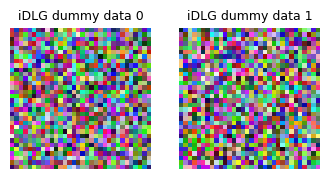

In [19]:
######### iDLG: recover the ground-truth labels from the leaked gradient #########
# original_dy_dx[-2] is the gradient of fc.weight, shape [num_classes, 768]. With batch size B the B rows with the most
# negative sums correspond to the classes present in the batch.
label_pred = torch.argsort(torch.sum(original_dy_dx[-2], dim=-1))[:BATCH_SIZE].detach().requires_grad_(False)
print("iDLG labels are", sorted(label_pred.tolist()), "\nGT labels are", sorted(gt_label.tolist()),
      "\nRecovered set is correct:", sorted(label_pred.tolist()) == sorted(gt_label.tolist()))

# generate dummy data (no dummy label anymore)
idlg_dummy_data = torch.rand(gt_data.size()).to(device).requires_grad_(True)  # uniform [0, 1], as in section 4

plt.figure(figsize=(4, 2.4))
for b in range(BATCH_SIZE):
    plt.subplot(1, BATCH_SIZE, b + 1)
    plt.imshow(tt(idlg_dummy_data[b].detach().cpu()))
    plt.title("iDLG dummy data %d" % b, fontsize=9)
    plt.axis('off')
plt.show()

In [20]:
idlg_criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.LBFGS([idlg_dummy_data], lr=1.0)

idlg_history = []
for iters in range(300):
    def closure():
        optimizer.zero_grad()

        pred = net(idlg_dummy_data)
        dummy_loss = idlg_criterion(pred, label_pred)
        dummy_dy_dx = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

        grad_diff = 0
        for gx, gy in zip(dummy_dy_dx, original_dy_dx):
            grad_diff += ((gx - gy) ** 2).sum()
        grad_diff.backward()

        return grad_diff

    optimizer.step(closure)
    if iters % 10 == 0:
        current_loss = closure()
        print(iters, "%.8f" % current_loss.item())
        if current_loss.item() < 0.000001: # converge
            break
    idlg_history.append(to_pil_list(idlg_dummy_data))

0 0.69921166
10 0.00520395
20 0.00213177
30 0.00129285
40 0.00092244
50 0.00072014
60 0.00058468
70 0.00048978
80 0.00043063
90 0.00038822
100 0.00034490
110 0.00031725
120 0.00028642
130 0.00026669
140 0.00025057
150 0.00023628
160 0.00022418
170 0.00021190
180 0.00019911
190 0.00018982
200 0.00017945
210 0.00017140
220 0.00016251
230 0.00015659
240 0.00015002
250 0.00014474
260 0.00013746
270 0.00013216
280 0.00012838
290 0.00012369


### Kết quả iDLG và so sánh với DLG

Figure đầu là quá trình optimize của các dummy image iDLG (mỗi hàng một ảnh, 10 mốc iteration cách đều nhau từ iteration đầu tiên đến cuối cùng). Figure sau đặt **ground truth, DLG và iDLG** cạnh nhau, sau khi ghép mỗi ảnh reconstruct với ảnh gốc gần nhất (`match_mse`).
Các dòng in ra so sánh **label** (iDLG, DLG, ground truth) và **MSE** giữa ảnh reconstruct với ground-truth image cho từng ảnh (MSE càng nhỏ, ảnh reconstruct càng giống ảnh gốc).

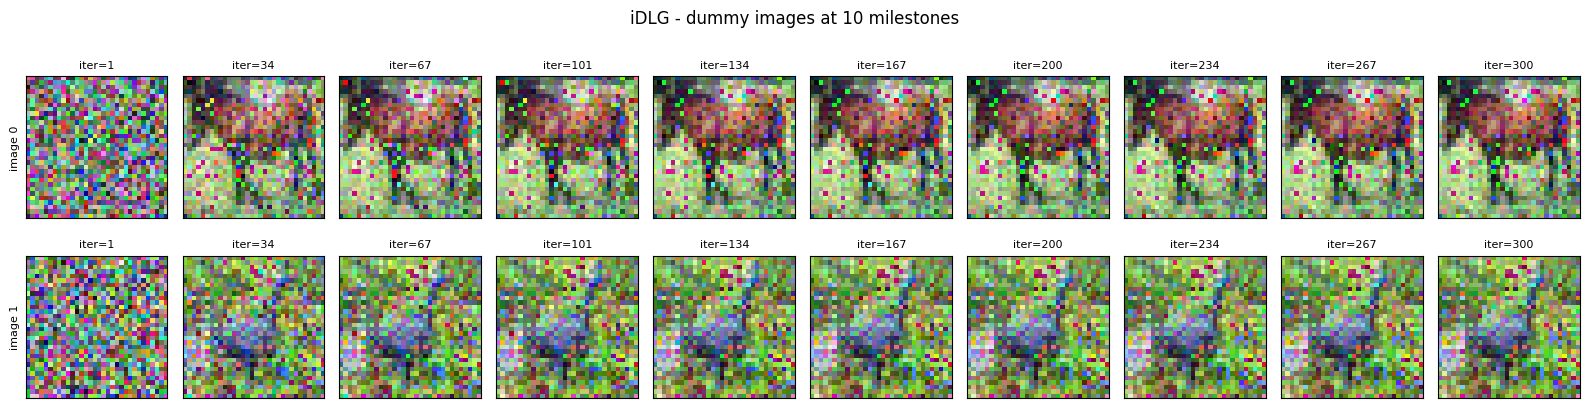

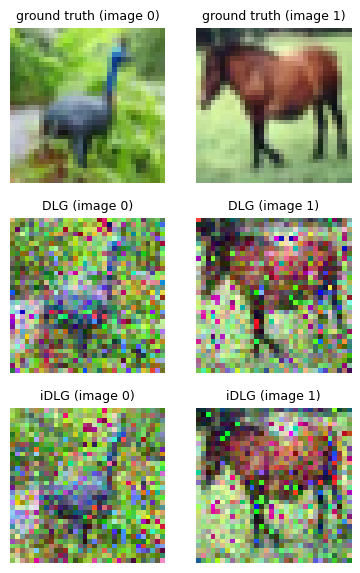

iDLG labels are [2, 7] | DLG labels are [2, 7] | GT labels are [2, 7]
MSE to ground truth (image 0) -> DLG: 0.02696817 | iDLG: 0.02530741
MSE to ground truth (image 1) -> DLG: 0.01995295 | iDLG: 0.01811968
Mean MSE over the batch -> DLG: 0.02346056 | iDLG: 0.02171355


In [21]:
show_history(idlg_history, "iDLG - dummy images at 10 milestones")

dlg_rec, dlg_mse = match_mse(dummy_data, gt_data)
idlg_rec, idlg_mse = match_mse(idlg_dummy_data, gt_data)

plt.figure(figsize=(2.2 * BATCH_SIZE, 7))
for b in range(BATCH_SIZE):
    for row, (name, x) in enumerate([("ground truth", gt_data), ("DLG", dlg_rec), ("iDLG", idlg_rec)]):
        plt.subplot(3, BATCH_SIZE, row * BATCH_SIZE + b + 1)
        plt.imshow(tt(x[b].detach().cpu()))
        plt.title("%s (image %d)" % (name, b), fontsize=9)
        plt.axis('off')
plt.show()

print("iDLG labels are", sorted(label_pred.tolist()), "| DLG labels are", sorted(torch.argmax(dummy_label, dim=-1).tolist()), "| GT labels are", sorted(gt_label.tolist()))
for b in range(BATCH_SIZE):
    print("MSE to ground truth (image %d) -> DLG: %.8f | iDLG: %.8f" % (b, dlg_mse[b].item(), idlg_mse[b].item()))
print("Mean MSE over the batch -> DLG: %.8f | iDLG: %.8f" % (dlg_mse.mean().item(), idlg_mse.mean().item()))

## 6. DP-SGD defense — gradient clipping + Gaussian noise (Abadi et al., 2016)

Defense được áp dụng **ở phía client, trước khi gradient rời khỏi thiết bị**, nên attacker chỉ thấy phiên bản đã bị biến đổi $\tilde g$.
Đầu tiên clip L2 norm toàn cục của gradient về ngưỡng $C$ (clipping threshold):

$$\mathrm{clip}(g, C) = g \cdot \min\!\left(1,\; \frac{C}{\lVert g \rVert_2}\right)$$

rồi cộng Gaussian noise với noise multiplier $\sigma$:

$$\tilde{g} = \mathrm{clip}(g, C) + \mathcal{N}\!\left(0,\; (\sigma C)^2 I\right)$$

$C$ càng lớn thì càng ít bị clip (giữ nhiều signal hơn); $\sigma$ càng lớn thì noise càng mạnh. Ta sweep lưới $(C, \sigma)$ và đo mức suy giảm chất lượng reconstruction.

- Attacker dùng **iDLG** làm attack tham chiếu (nhanh và ổn định hơn DLG), recover 2 label **từ gradient đã bị defense** (2 hàng có tổng gradient âm nhất) rồi reconstruct **cả hai ảnh** của batch.
- Metrics: **MSE** giữa ảnh reconstruct và ground-truth image (trung bình của hai ảnh, sau khi ghép bằng `match_mse`), và **PSNR** $= 10\log_{10}(1/\mathrm{MSE})$ (data range $R=1$; PSNR càng cao thì ảnh reconstruct càng giống ảnh gốc).
- Để chạy nhanh, lưới chỉ có **2 giá trị $C$ × 4 giá trị $\sigma$ = 8 cấu hình**, mỗi cấu hình chạy `NUM_ITERS_DEFENSE = 50` iterations L-BFGS (ít hơn 300 ở mục 4–5). Nếu muốn kết quả chi tiết hơn, tăng `NUM_ITERS_DEFENSE` hoặc mở rộng `clip_norms` / `noise_stds`.
- Các giá trị $C$ được chọn theo **global L2 norm** của gradient gốc (in ra ở đầu output): $C$ lớn hơn norm thì gradient không bị clip, còn $C$ nhỏ hơn norm thì gradient bị thu nhỏ. Lưu ý gradient ở đây là trung bình của batch 2 ảnh nên norm có thể khác với trường hợp batch size = 1.

In [22]:
import pandas as pd

# Lưới nhỏ (2 x 4 = 8 cấu hình) và ít iterations để chạy nhanh. C được chọn theo global L2 norm của gradient (in ra bên dưới):
# C > norm -> không bị clip, C < norm -> gradient bị thu nhỏ. Noise thực tế trên mỗi phần tử là sigma * C.
clip_norms = [10.0, 30.0]
noise_stds = [0.0, 0.0001, 0.001, 0.01]
NUM_ITERS_DEFENSE = 50

total_norm = torch.sqrt(sum((g ** 2).sum() for g in original_dy_dx))
print("Global L2 norm of the original gradient: %.4f" % total_norm.item())

defense_results = []
for C in clip_norms:
    for sigma in noise_stds:
        # ---- client side: clip the global L2 norm, then add Gaussian noise N(0, (sigma * C)^2) to every tensor ----
        clip_coef = torch.clamp(C / (total_norm + 1e-6), max=1.0)
        defended_dy_dx = [g * clip_coef + torch.randn_like(g) * sigma * C for g in original_dy_dx]

        # ---- attacker side: iDLG on the defended gradient (labels are recovered from the defended gradient too) ----
        def_label_pred = torch.argsort(torch.sum(defended_dy_dx[-2], dim=-1))[:BATCH_SIZE].detach().requires_grad_(False)
        def_dummy_data = torch.rand(gt_data.size()).to(device).requires_grad_(True)   # uniform [0, 1], as in section 4
        optimizer = torch.optim.LBFGS([def_dummy_data], lr=1.0)

        for iters in range(NUM_ITERS_DEFENSE):
            def closure():
                optimizer.zero_grad()

                pred = net(def_dummy_data)
                dummy_loss = idlg_criterion(pred, def_label_pred)
                dummy_dy_dx = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

                grad_diff = 0
                for gx, gy in zip(dummy_dy_dx, defended_dy_dx):
                    grad_diff += ((gx - gy) ** 2).sum()
                grad_diff.backward()

                return grad_diff

            optimizer.step(closure)

        aligned, per_img_mse = match_mse(def_dummy_data, gt_data)      # re-order the reconstructions like the ground truth
        mse = per_img_mse.mean().item()
        defense_results.append({
            "clip_norm": C, "noise_std": sigma,
            "mse": mse, "psnr": -10 * np.log10(mse),
            "label_correct": sorted(def_label_pred.tolist()) == sorted(gt_label.tolist()),
            "image": aligned.cpu(),
        })
        print("[%2d/%d] C=%s, sigma=%s -> MSE %.6f, PSNR %.2f dB, labels %s" % (
            len(defense_results), len(clip_norms) * len(noise_stds), C, sigma,
            mse, defense_results[-1]["psnr"], "correct" if defense_results[-1]["label_correct"] else "WRONG"))

defense_df = pd.DataFrame(defense_results)
defense_df.drop(columns="image")

Global L2 norm of the original gradient: 25.1705
[ 1/8] C=10.0, sigma=0.0 -> MSE 1.399240, PSNR -1.46 dB, labels correct
[ 2/8] C=10.0, sigma=0.0001 -> MSE 1.400294, PSNR -1.46 dB, labels correct
[ 3/8] C=10.0, sigma=0.001 -> MSE 10.146133, PSNR -10.06 dB, labels correct
[ 4/8] C=10.0, sigma=0.01 -> MSE 56.263557, PSNR -17.50 dB, labels correct
[ 5/8] C=30.0, sigma=0.0 -> MSE 0.032008, PSNR 14.95 dB, labels correct
[ 6/8] C=30.0, sigma=0.0001 -> MSE 0.119914, PSNR 9.21 dB, labels correct
[ 7/8] C=30.0, sigma=0.001 -> MSE 16.372181, PSNR -12.14 dB, labels correct
[ 8/8] C=30.0, sigma=0.01 -> MSE 74.366257, PSNR -18.71 dB, labels correct


,clip_norm,noise_std,mse,psnr,label_correct
0,10.0,0.0000,1.399240,-1.458921,True
1,10.0,0.0001,1.400294,-1.462194,True
2,10.0,0.0010,10.146133,-10.063006,True
3,10.0,0.0100,56.263557,-17.502272,True
4,30.0,0.0000,0.032008,14.947386,True
5,30.0,0.0001,0.119914,9.211284,True
6,30.0,0.0010,16.372181,-12.141065,True
7,30.0,0.0100,74.366257,-18.713759,True


### Chất lượng reconstruction theo noise level

Trục hoành là noise multiplier $\sigma$ (thang `symlog` để hiển thị được cả $\sigma = 0$), mỗi đường ứng với một clipping threshold $C$.
**PSNR giảm** (hoặc **MSE tăng**) khi $\sigma$ tăng nghĩa là defense hiệu quả hơn.

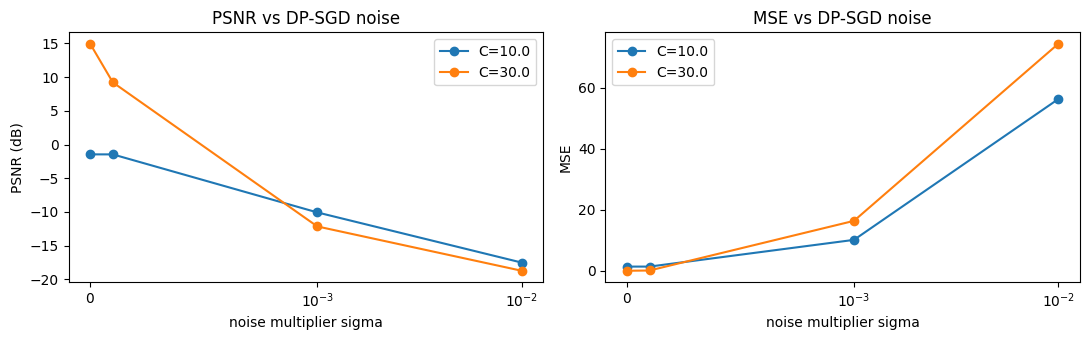

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for C, group in defense_df.groupby("clip_norm"):
    axes[0].plot(group["noise_std"], group["psnr"], marker="o", label="C=%s" % C)
    axes[1].plot(group["noise_std"], group["mse"], marker="o", label="C=%s" % C)
axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("PSNR vs DP-SGD noise")
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE vs DP-SGD noise")
for ax in axes:
    ax.set_xscale("symlog", linthresh=1e-3)
    ax.set_xlabel("noise multiplier sigma")
    ax.legend()
plt.tight_layout()
plt.show()

### Ảnh reconstruct theo noise level (cố định clipping threshold $C$)

Mỗi hàng là một ảnh của batch: ô đầu là ground-truth image, các ô sau là ảnh iDLG reconstruct với $\sigma$ tăng dần. Mục đích là xem bằng mắt tại noise level nào ảnh không còn nhận ra được.

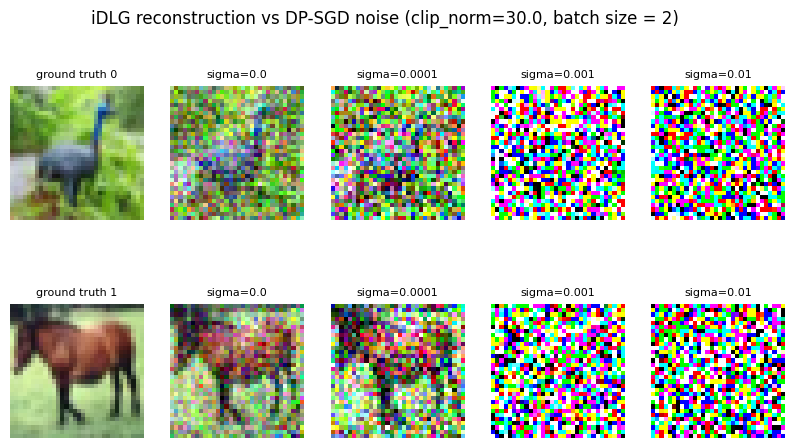

In [24]:
C_fixed = 30.0
chosen = [r for r in defense_results if r["clip_norm"] == C_fixed]

plt.figure(figsize=(2 * (len(chosen) + 1), 2.6 * BATCH_SIZE))
for b in range(BATCH_SIZE):
    plt.subplot(BATCH_SIZE, len(chosen) + 1, b * (len(chosen) + 1) + 1)
    plt.imshow(tt(gt_data[b].cpu()))
    plt.title("ground truth %d" % b, fontsize=8)
    plt.axis('off')
    for k, r in enumerate(chosen):
        plt.subplot(BATCH_SIZE, len(chosen) + 1, b * (len(chosen) + 1) + k + 2)
        plt.imshow(tt(r["image"][b].clamp(0, 1)))
        plt.title("sigma=%s" % r["noise_std"], fontsize=8)
        plt.axis('off')
plt.suptitle("iDLG reconstruction vs DP-SGD noise (clip_norm=%s, batch size = %d)" % (C_fixed, BATCH_SIZE))
plt.show()